In [22]:
import os

# set your default path here
os.chdir("/Users/aditya/Downloads/Medisyn_Labs_case_study")

# confirm
print("Current Working Directory:", os.getcwd())


Current Working Directory: /Users/aditya/Downloads/Medisyn_Labs_case_study


Data loaded and combined successfully.
Cohorts assigned using simple rules.

--- Size of Each Customer Cohort ---
On-the-Fence                    1660
Advocates (General Wellness)    1305
Dissatisfied                     902
Advocates (Pain Relief)          276
Name: Cohort, dtype: int64


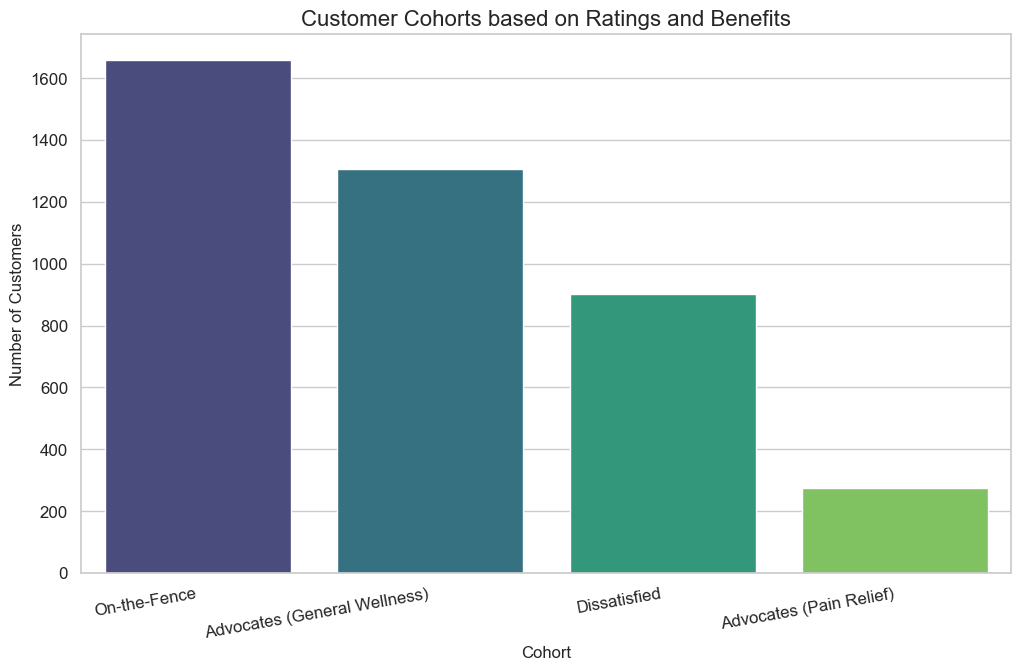


Analysis complete. Results saved to 'customer_cohorts_simple_analysis.csv'


In [25]:
# ==============================================================================
# Step 1: Setup and Data Loading
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and combine the datasets
try:
    train_df = pd.read_csv('train.tsv', sep='\t', header=None)
    test_df = pd.read_csv('test.tsv', sep='\t', header=None)
except FileNotFoundError:
    print("Ensure 'train.tsv' and 'test.tsv' are in the same directory.")
    exit()

# Define and assign column names
column_names = [
    'CustomerID', 'Medicine', 'Rating', 'Effectiveness', 'Side Effects',
    'Condition', 'Benefits', 'Side Effects Review', 'Comments'
]
train_df.columns = column_names
test_df.columns = column_names
df = pd.concat([train_df, test_df], ignore_index=True)

print("Data loaded and combined successfully.")

# ==============================================================================
# Step 2: Define Cohorts with Simple, Explainable Rules
# ==============================================================================
# This is the core of our solution. We define groups based on clear logic.

def assign_cohort(row):
    rating = row['Rating']
    benefits_text = str(row['Benefits']).lower() # Ensure text is lowercase string

    # Rule 1: Identify Dissatisfied customers first (lowest ratings)
    if rating <= 4:
        return 'Dissatisfied'

    # Rule 2: Identify Advocates (highest ratings)
    if rating >= 9:
        # We can even look for keywords to create sub-groups of advocates
        if 'pain' in benefits_text or 'cramp' in benefits_text or 'relief' in benefits_text:
            return 'Advocates (Pain Relief)'
        else:
            return 'Advocates (General Wellness)'

    # Rule 3: Everyone else falls into the "On-the-Fence" category
    if rating >= 5 and rating <= 8:
        return 'On-the-Fence'

    # A fallback for any unexpected cases
    return 'Other'


# Apply this function to create the 'Cohort' column
df['Cohort'] = df.apply(assign_cohort, axis=1)

print("Cohorts assigned using simple rules.")

# ==============================================================================
# Step 3: Analyze and Visualize the Cohorts
# ==============================================================================
# Now we show the results of our logical grouping.

print("\n--- Size of Each Customer Cohort ---")
print(df['Cohort'].value_counts())


# Plot the size of each cohort
plt.figure(figsize=(12, 7))
sns.countplot(x='Cohort', data=df, order=df['Cohort'].value_counts().index, palette='viridis')
plt.title('Customer Cohorts based on Ratings and Benefits', fontsize=16)
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('Cohort', fontsize=12)
plt.xticks(rotation=10, ha="right")
plt.show()

# Save the final results to a CSV file
df.to_csv('customer_cohorts_simple_analysis.csv', index=False)
print("\nAnalysis complete. Results saved to 'customer_cohorts_simple_analysis.csv'")

In [26]:
# ==============================================================================
# Step 1: Setup and Data Loading
# ==============================================================================
# This line helps prevent a common environment-specific error with scikit-learn
import os
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns

# Load and combine the datasets
try:
    train_df = pd.read_csv('train.tsv', sep='\t', header=None)
    test_df = pd.read_csv('test.tsv', sep='\t', header=None)
except FileNotFoundError:
    print("Ensure 'train.tsv' and 'test.tsv' are in the same directory.")
    exit()

# Define and assign column names
column_names = [
    'CustomerID', 'Medicine', 'Rating', 'Effectiveness', 'Side Effects',
    'Condition', 'Benefits', 'Side Effects Review', 'Comments'
]
train_df.columns = column_names
test_df.columns = column_names
df = pd.concat([train_df, test_df], ignore_index=True)

print("Data loaded and combined successfully.")

# ==============================================================================
# Step 2: Feature Engineering (Rating + Benefits Text)
# ==============================================================================
# 1. Clean the 'Benefits' text data
df['Benefits_Clean'] = df['Benefits'].fillna('').apply(
    lambda text: re.sub(f'[{re.escape(string.punctuation)}]', '', text.lower())
)

# 2. Vectorize the text data using TF-IDF
# We'll limit to 1000 features to keep it focused on the most important words.
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
text_features = tfidf.fit_transform(df['Benefits_Clean'])

# 3. Scale the 'Rating' column
scaler = MinMaxScaler()
rating_feature = scaler.fit_transform(df[['Rating']])

# 4. Combine the text features and the rating feature
# The `hstack` function is used to combine sparse (text) and dense (rating) matrices.
combined_features = hstack([text_features, rating_feature])

print("Features from 'Rating' and 'Benefits' are prepared.")

# ==============================================================================
# Step 3: K-Means Clustering
# ==============================================================================
# We will group the customers into 4 distinct cohorts.
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(combined_features)

# Assign the identified cohort to each customer
df['Cohort'] = kmeans.labels_

print("Clustering complete. Cohorts have been assigned.")

# ==============================================================================
# Step 4: Analyze and Visualize the Cohorts
# ==============================================================================
# This step is key to understanding what each cohort represents.

print("\n--- Analysis of Customer Cohorts ---")

# Get the top keywords for each cohort
feature_names = tfidf.get_feature_names_out()
centroids = kmeans.cluster_centers_

for i in range(k):
    cohort_df = df[df['Cohort'] == i]
    
    # Get the centroid for the current cluster (only the text part)
    text_centroid = centroids[i, :-1] # Exclude the last value, which is the rating
    top_keyword_indices = text_centroid.argsort()[-10:][::-1] # Get top 10 word indices
    top_keywords = [feature_names[index] for index in top_keyword_indices]
    
    print(f"\n--- Cohort {i} ---")
    print(f"Number of Customers: {len(cohort_df)}")
    print(f"Average Rating: {cohort_df['Rating'].mean():.2f}")
    print(f"Top 10 Keywords in Benefits: {', '.join(top_keywords)}")


# To make the visualization clearer, let's name the cohorts based on our analysis
# (Note: Check the summary above to confirm the mapping for your run)
cohort_names = {
    0: 'Moderately Satisfied',
    1: 'Highly Satisfied (Pain/Cramp Relief)',
    2: 'Dissatisfied / Neutral',
    3: 'Highly Satisfied (General Wellness)'
}
df['Cohort_Name'] = df['Cohort'].map(cohort_names)

# Plot the size of each cohort
plt.figure(figsize=(12, 7))
sns.countplot(x='Cohort_Name', data=df, order=df['Cohort_Name'].value_counts().index, palette='viridis')
plt.title('Customer Cohorts based on Ratings and Benefits', fontsize=16)
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('Cohort', fontsize=12)
plt.xticks(rotation=10, ha="right")
plt.show()

# Save the final results to a CSV file
df.to_csv('customer_cohorts_benefits_analysis.csv', index=False)
print("\nAnalysis complete. Results saved to 'customer_cohorts_benefits_analysis.csv'")

Data loaded and combined successfully.
Features from 'Rating' and 'Benefits' are prepared.


AttributeError: 'NoneType' object has no attribute 'split'